<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/phase1-foundations/day13_logisticregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy : 0.8525
ROC-AUC  : 0.9267

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



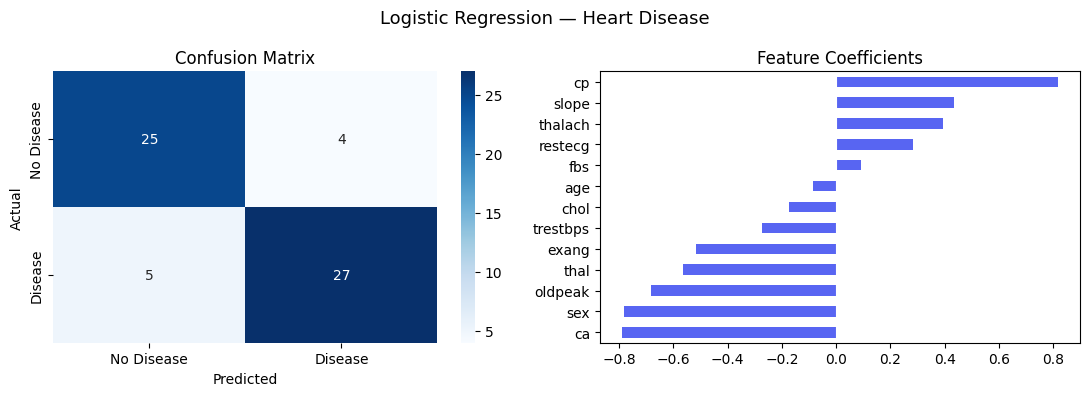

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score)
import seaborn as sns

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df  = pd.read_csv(url)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

y_pred      = model.predict(X_test_s)
y_proba     = model.predict_proba(X_test_s)[:, 1]
accuracy    = accuracy_score(y_test, y_pred)
roc_auc     = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Logistic Regression — Heart Disease", fontsize=13)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"])
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
axes[0].set_title("Confusion Matrix")

coef_series = pd.Series(model.coef_[0], index=X.columns).sort_values()
coef_series.plot(kind="barh", ax=axes[1], color="#5865F2")
axes[1].axvline(0, color="white", lw=0.8)
axes[1].set_title("Feature Coefficients")

plt.tight_layout()
plt.savefig("day13_logistic_regression.png", dpi=150)
plt.show()